# Home Credit Default Risk
 https://www.kaggle.com/datasets/megancrenshaw/home-credit-default-risk

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos
Se parte de `eight_columns.csv`, que contiene las variables seleccionadas para el taller. Como ese fichero no incluye el identificador de cliente, se recupera `SK_ID_CURR` desde `application_train.csv` y se usa como indice para mantener trazabilidad por cliente.

In [2]:
df = pd.read_csv('eight_columns.csv')

client_ids = pd.read_csv('application_train.csv', usecols=['SK_ID_CURR'])
assert len(client_ids) == len(df), 'SK_ID_CURR no esta alineado con eight_columns.csv'

df.index = client_ids['SK_ID_CURR']
df.index.name = 'SK_ID_CURR'

In [3]:
df.shape

(307511, 9)

## EDA 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 100002 to 456255
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   TARGET            307511 non-null  int64  
 1   CODE_GENDER       307511 non-null  object 
 2   AMT_INCOME_TOTAL  307511 non-null  float64
 3   AMT_CREDIT        307511 non-null  float64
 4   AMT_ANNUITY       307499 non-null  float64
 5   DAYS_BIRTH        307511 non-null  int64  
 6   EXT_SOURCE_1      134133 non-null  float64
 7   EXT_SOURCE_2      306851 non-null  float64
 8   EXT_SOURCE_3      246546 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 23.5+ MB


In [5]:
df.describe()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,307511.000000,3.075110e+05,3.075110e+05,307499.000000,307511.000000,134133.000000,3.068510e+05,246546.000000
mean,0.080729,1.687979e+05,5.990260e+05,27108.573909,-16036.995067,0.502130,5.143927e-01,0.510853
std,0.272419,2.371231e+05,4.024908e+05,14493.737315,4363.988632,0.211062,1.910602e-01,0.194844
min,0.000000,2.565000e+04,4.500000e+04,1615.500000,-25229.000000,0.014568,8.173617e-08,0.000527
25%,0.000000,1.125000e+05,2.700000e+05,16524.000000,-19682.000000,0.334007,3.924574e-01,0.370650
50%,0.000000,1.471500e+05,5.135310e+05,24903.000000,-15750.000000,0.505998,5.659614e-01,0.535276
75%,0.000000,2.025000e+05,8.086500e+05,34596.000000,-12413.000000,0.675053,6.636171e-01,0.669057
max,1.000000,1.170000e+08,4.050000e+06,258025.500000,-7489.000000,0.962693,8.549997e-01,0.896010


In [6]:
df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

### Missing values
Primero se mide el volumen de nulos. Para `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` se guarda un flag binario de incertidumbre antes de imputar, de forma que el modelo pueda distinguir un valor observado de un valor rellenado.

In [7]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table = mis_val_table.rename(
        columns={0: 'Missing Values', 1: '% of Total Values'}
    )

    mis_val_table = (
        mis_val_table[mis_val_table.iloc[:, 1] != 0]
        .sort_values('% of Total Values', ascending=False)
        .round(1)
    )

    print(
        'Your selected dataframe has ' + str(df.shape[1]) + ' columns.\n'
        'There are ' + str(mis_val_table.shape[0]) + ' columns that have missing values.'
    )

    return mis_val_table

In [8]:
missing_values = missing_values_table(df)
missing_values.head(20)

Your selected dataframe has 9 columns.
There are 4 columns that have missing values.


,Missing Values,% of Total Values
EXT_SOURCE_1,173378,56.4
EXT_SOURCE_3,60965,19.8
EXT_SOURCE_2,660,0.2
AMT_ANNUITY,12,0.0


In [9]:
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
flag_cols = [f'{col}_MISSING' for col in ext_source_cols]

# Flags binarios: 1 si el EXT_SOURCE venia vacio originalmente, 0 si estaba observado.
flags_missing = df[ext_source_cols].isna().astype(int)
flags_missing.columns = flag_cols
flags_missing.index.name = 'SK_ID_CURR'

flags_missing.to_csv('ext_source_missing_flags.csv')
flags_missing.head()

,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING
SK_ID_CURR,,,
100002,0,0,0
100003,0,0,1
100004,1,0,0
100006,1,0,1
100007,1,0,1


### Desbalanceo de clases

- Hay menos hombres que mujeres.
- En esta muestra, los hombres tienen mayor proporcion de `TARGET = 1`.
- Los valores `XNA` de genero se imputan como hombre por su impacto minimo.
- El `TARGET` esta desbalanceado: aproximadamente 90% clase 0 y 10% clase 1.

<Axes: xlabel='TARGET'>

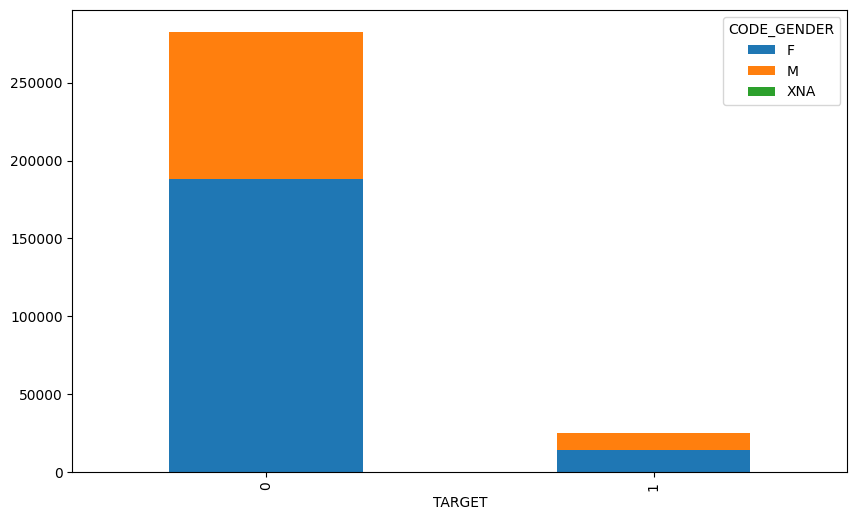

In [10]:
# Comprobar el desbalanceo entre TARGET y genero.
df.groupby(['TARGET', 'CODE_GENDER']).size().unstack().plot(
    kind='bar', stacked=True, figsize=(10, 6)
)

### Variable categorica sensible
`CODE_GENDER` es la variable sensible. Se codifica como 0 para hombre y 1 para mujer; los valores no informados (`XNA`) se asignan a 0 por su frecuencia residual.

In [11]:
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0).astype(int)

### Correlation Matrix

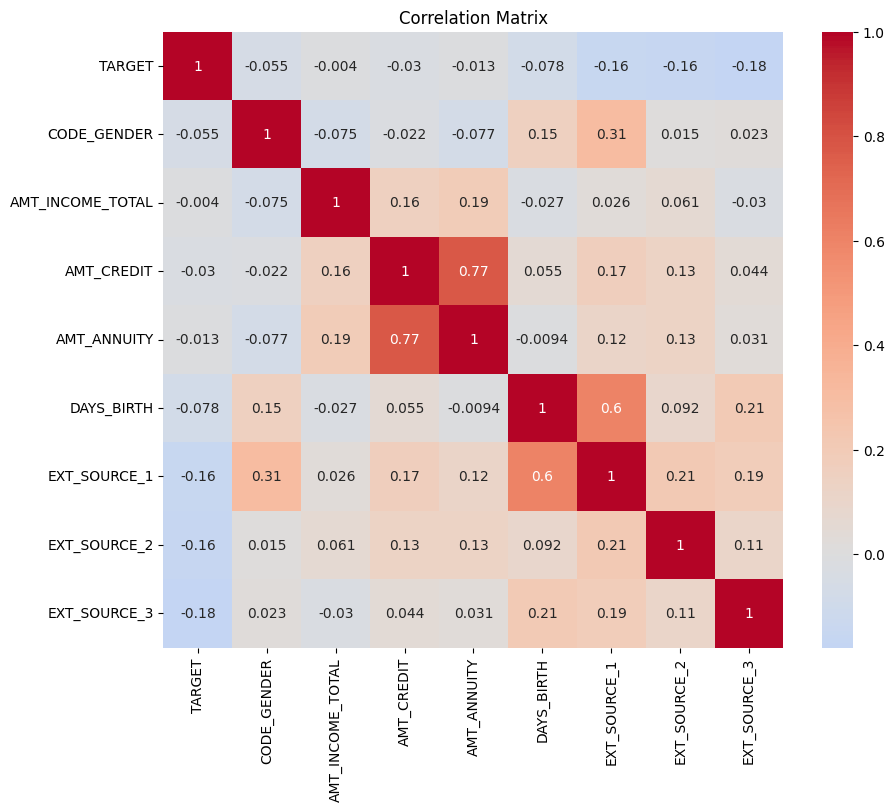

In [12]:
# matriz de correlaciones entre todas las variables

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

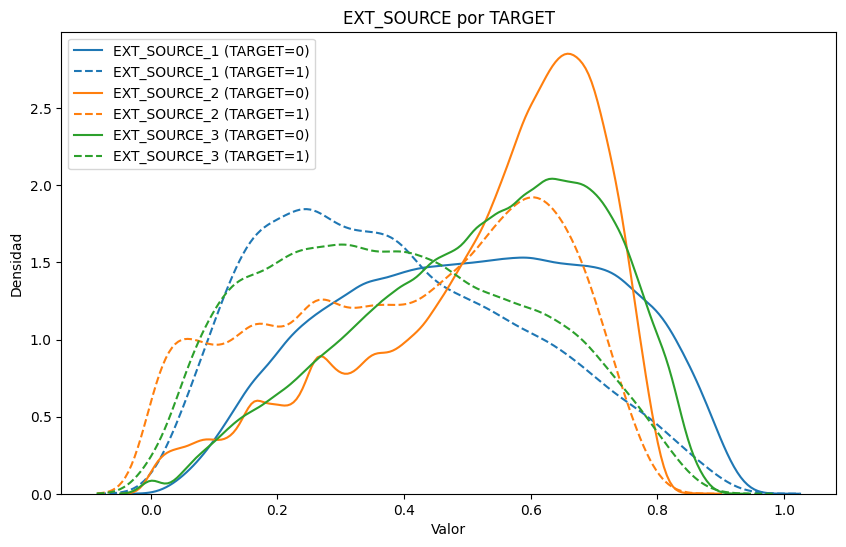

In [13]:
plt.figure(figsize=(10,6))

variables = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
colores = ['tab:blue', 'tab:orange', 'tab:green']

for var, color in zip(variables, colores):

    sns.kdeplot(
        data=df[df['TARGET']==0],
        x=var,
        color=color,
        linestyle='-',
        label=f'{var} (TARGET=0)'
    )

    sns.kdeplot(
        data=df[df['TARGET']==1],
        x=var,
        color=color,
        linestyle='--',
        label=f'{var} (TARGET=1)'
    )

plt.title('EXT_SOURCE por TARGET')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.show()

## Ratio de endeudamiento
Se crea una variable derivada sencilla: credito solicitado dividido entre ingresos totales.

In [14]:
df['RATIO_ENDEUDAMIENTO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df[['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'RATIO_ENDEUDAMIENTO']].head()

,AMT_CREDIT,AMT_INCOME_TOTAL,RATIO_ENDEUDAMIENTO
SK_ID_CURR,,,
100002,406597.5,202500.0,2.007889
100003,1293502.5,270000.0,4.790750
100004,135000.0,67500.0,2.000000
100006,312682.5,135000.0,2.316167
100007,513000.0,121500.0,4.222222


¿Relación entre el ratio de endeudamiento y el la edad?

/tmp/ipykernel_1610/4038338465.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 6000), random_state=42))


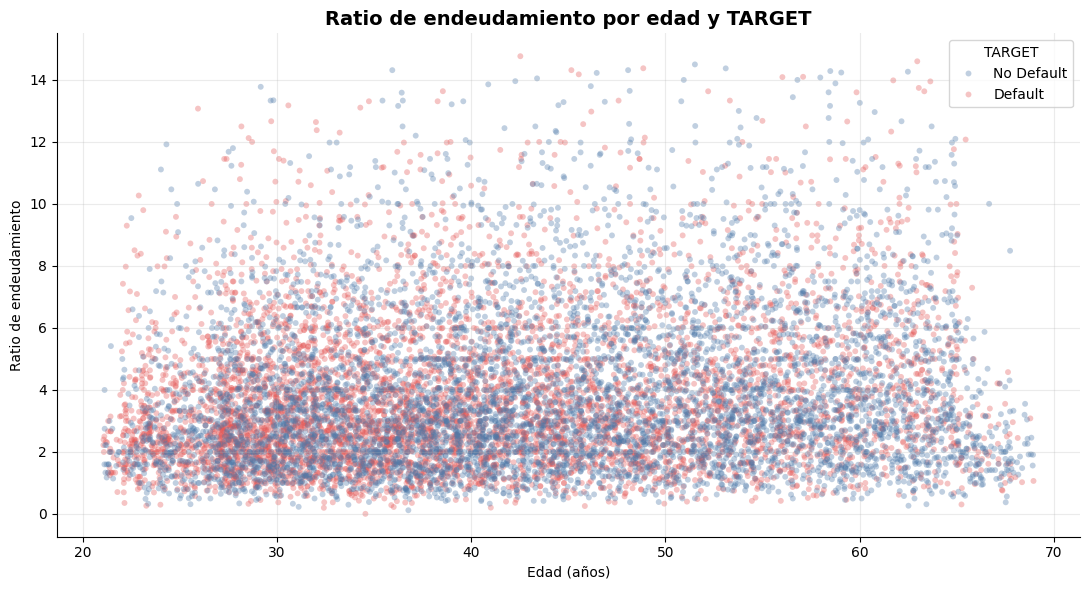

In [15]:
# Scatterplot entre RATIO_ENDEUDAMIENTO y DAYS_BIRTH, coloreado por TARGET
plot_df = df[['DAYS_BIRTH', 'RATIO_ENDEUDAMIENTO', 'TARGET']].dropna().copy()
plot_df['TARGET_LABEL'] = plot_df['TARGET'].map({0: 'No Default', 1: 'Default'})

# Recorte visual para que los outliers no aplasten la nube principal de puntos
limite_y = plot_df['RATIO_ENDEUDAMIENTO'].quantile(0.995)
plot_df = plot_df[plot_df['RATIO_ENDEUDAMIENTO'].between(0, limite_y)]

# Muestra estratificada: mejora la legibilidad y conserva ambas clases
plot_sample = (
    plot_df
    .groupby('TARGET_LABEL', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 6000), random_state=42))
)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=plot_sample,
    x='DAYS_BIRTH',
    y='RATIO_ENDEUDAMIENTO',
    hue='TARGET_LABEL',
    hue_order=['No Default', 'Default'],
    palette={'No Default': '#4C78A8', 'Default': '#E45756'},
    alpha=0.35,
    s=18,
    linewidth=0,
)

plt.title('Ratio de endeudamiento por edad y TARGET', fontsize=14, weight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Ratio de endeudamiento')
plt.grid(True, alpha=0.25)
plt.legend(title='TARGET', frameon=True)
sns.despine()
plt.tight_layout()



In [16]:
import keras
import tensorflow as tf
print(f'Keras version: {keras.__version__}')
print(f'TensorFlow version: {tf.__version__}')


2026-06-23 18:16:38.179024: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 18:16:38.481194: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-23 18:16:39.753924: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Keras version: 2.13.1
TensorFlow version: 2.13.0


# Train/test split
El split separa `X`, `y`, la variable sensible `s` y los flags de missing en una unica llamada a `train_test_split`. Asi `flags_train` y `flags_test` conservan exactamente el mismo indice y orden que `X_train` y `X_test`.

La imputacion por mediana se calcula solo con `X_train` para evitar leakage y despues se aplica a `X_train` y `X_test`. El escalado tambien se ajusta solo con train.

In [17]:
# Separar variables principales, target, variable sensible y flags de incertidumbre.
X = df.drop(columns=['TARGET'])
y = df['TARGET']
s = df['CODE_GENDER']
flags = flags_missing

# Split conjunto para conservar alineacion exacta por SK_ID_CURR.
X_train, X_test, y_train, y_test, s_train, s_test, flags_train, flags_test = train_test_split(
    X, y, s, flags,
    test_size=0.2,
    random_state=42,
    stratify=y
)

assert X_train.index.equals(flags_train.index)
assert X_test.index.equals(flags_test.index)

# Imputacion por mediana ajustada solo con train para evitar data leakage.
median_impute_cols = X_train.columns[X_train.isna().any()].tolist()
train_medians = X_train[median_impute_cols].median()

X_train = X_train.copy()
X_test = X_test.copy()
X_train[median_impute_cols] = X_train[median_impute_cols].fillna(train_medians)
X_test[median_impute_cols] = X_test[median_impute_cols].fillna(train_medians)

# Copia de las variables antes de aplicar StandardScaler.
X_train_pre_scaler = X_train.copy()
X_test_pre_scaler = X_test.copy()

# Escalado solo usando el train set para evitar data leakage.
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print('Columnas imputadas con mediana de train:', median_impute_cols)
print('Alineacion flags_train:', X_train.index.equals(flags_train.index))
print('Alineacion flags_test:', X_test.index.equals(flags_test.index))

Columnas imputadas con mediana de train: ['AMT_ANNUITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
Alineacion flags_train: True
Alineacion flags_test: True


In [18]:
y_train_reshaped = y_train.to_numpy().reshape(-1, 1)
combined_data_train_pre_scaler = np.hstack((X_train_pre_scaler.to_numpy(), y_train_reshaped))
combined_data_train = np.hstack((X_train.to_numpy(), y_train_reshaped))

print('Shape of the combined pre-scaler training data matrix:', combined_data_train_pre_scaler.shape)
print('Shape of the combined training data matrix:', combined_data_train.shape)
print('First 5 rows of the combined training data matrix:\n', combined_data_train[:5, :])

Shape of the combined pre-scaler training data matrix: (246008, 10)
Shape of the combined training data matrix: (246008, 10)
First 5 rows of the combined training data matrix:
 [[ 7.20852196e-01 -3.04499338e-01 -9.23256046e-01 -9.58535684e-01
  -8.55291193e-01 -8.53252903e-01 -1.17759094e+00  6.13835656e-01
  -5.32594385e-01  0.00000000e+00]
 [-1.38724694e+00 -3.04499338e-01 -1.08661816e+00 -9.65043686e-01
  -1.50019908e-01  1.18607519e-02 -8.04982301e-04  1.12012338e-01
  -8.04585165e-01  0.00000000e+00]
 [-1.38724694e+00 -1.30727397e-01  3.21581141e-01 -5.51630671e-02
   7.51223736e-01  1.18607519e-02 -1.44074162e-01  4.76445732e-01
   5.35598861e-01  1.00000000e+00]
 [-1.38724694e+00 -1.30727397e-01 -3.10771031e-01  5.18470797e-01
   4.03745261e-01  1.18607519e-02  8.44742421e-01 -3.51503603e-01
  -1.66293624e-01  1.00000000e+00]
 [ 7.20852196e-01  4.30445426e-02 -8.55765816e-01  3.09904793e-02
  -1.72902995e+00  1.18607519e-02 -1.88468124e+00  1.12012338e-01
  -9.46719881e-01  0.00

In [19]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('s_train:', s_train.shape)
print('flags_train:', flags_train.shape)
print('flags_test:', flags_test.shape)
print('combined_data_train_pre_scaler:', combined_data_train_pre_scaler.shape)
print('combined_data_train:', combined_data_train.shape)

X_train: (246008, 9)
X_test: (61503, 9)
y_train: (246008,)
s_train: (246008,)
flags_train: (246008, 3)
flags_test: (61503, 3)
combined_data_train_pre_scaler: (246008, 10)
combined_data_train: (246008, 10)


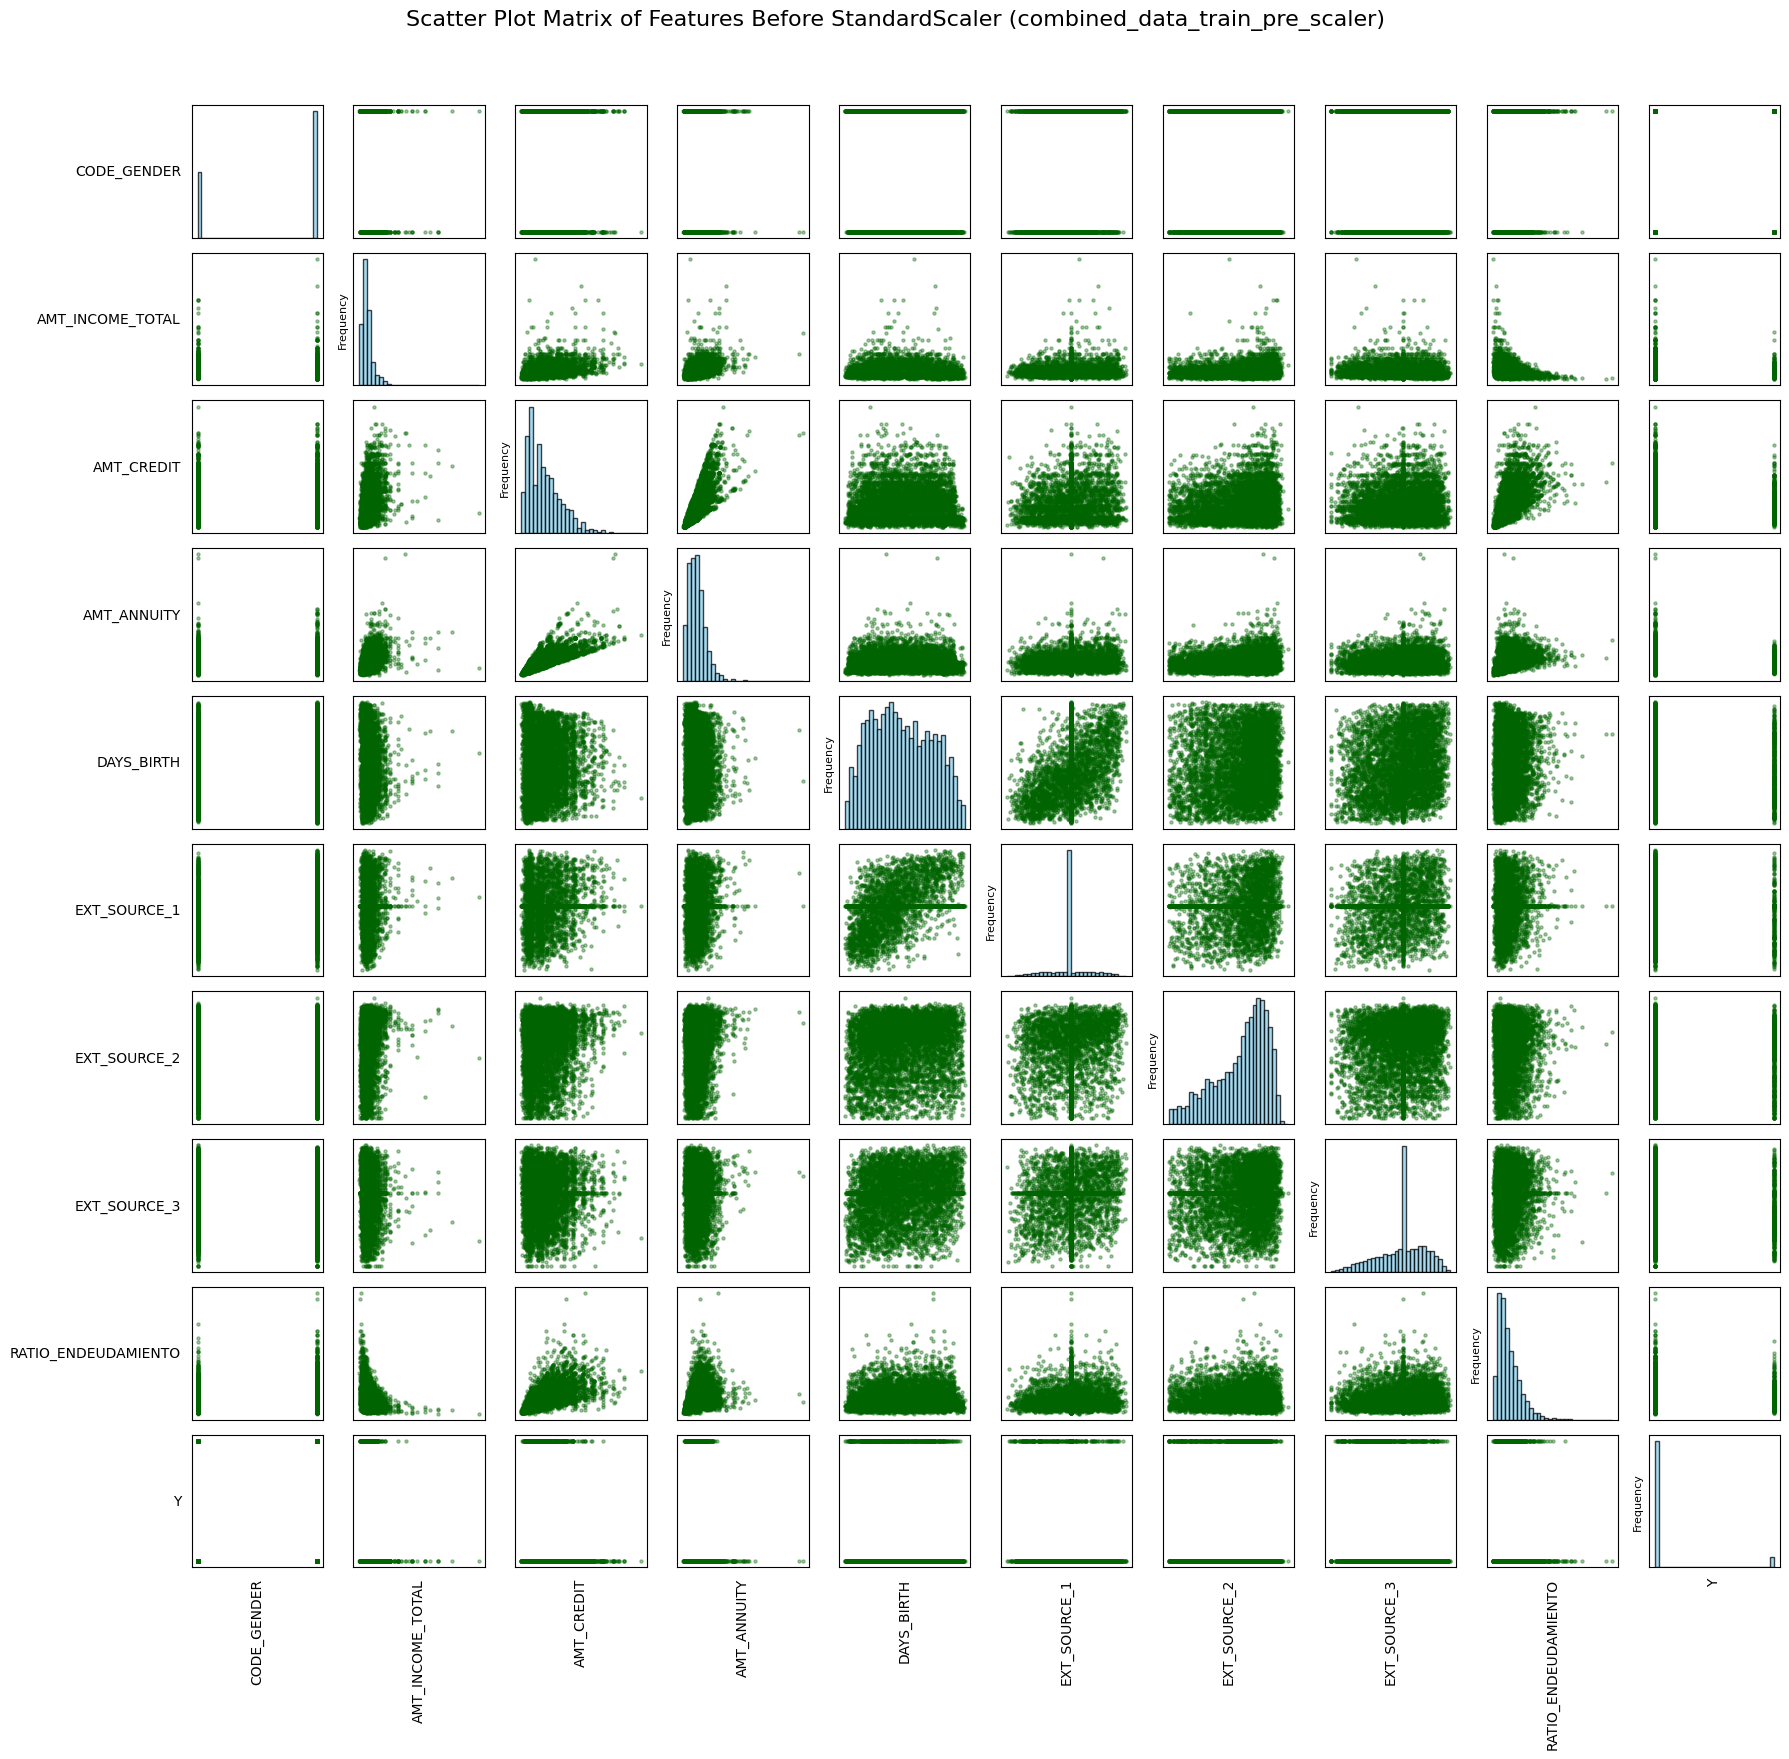

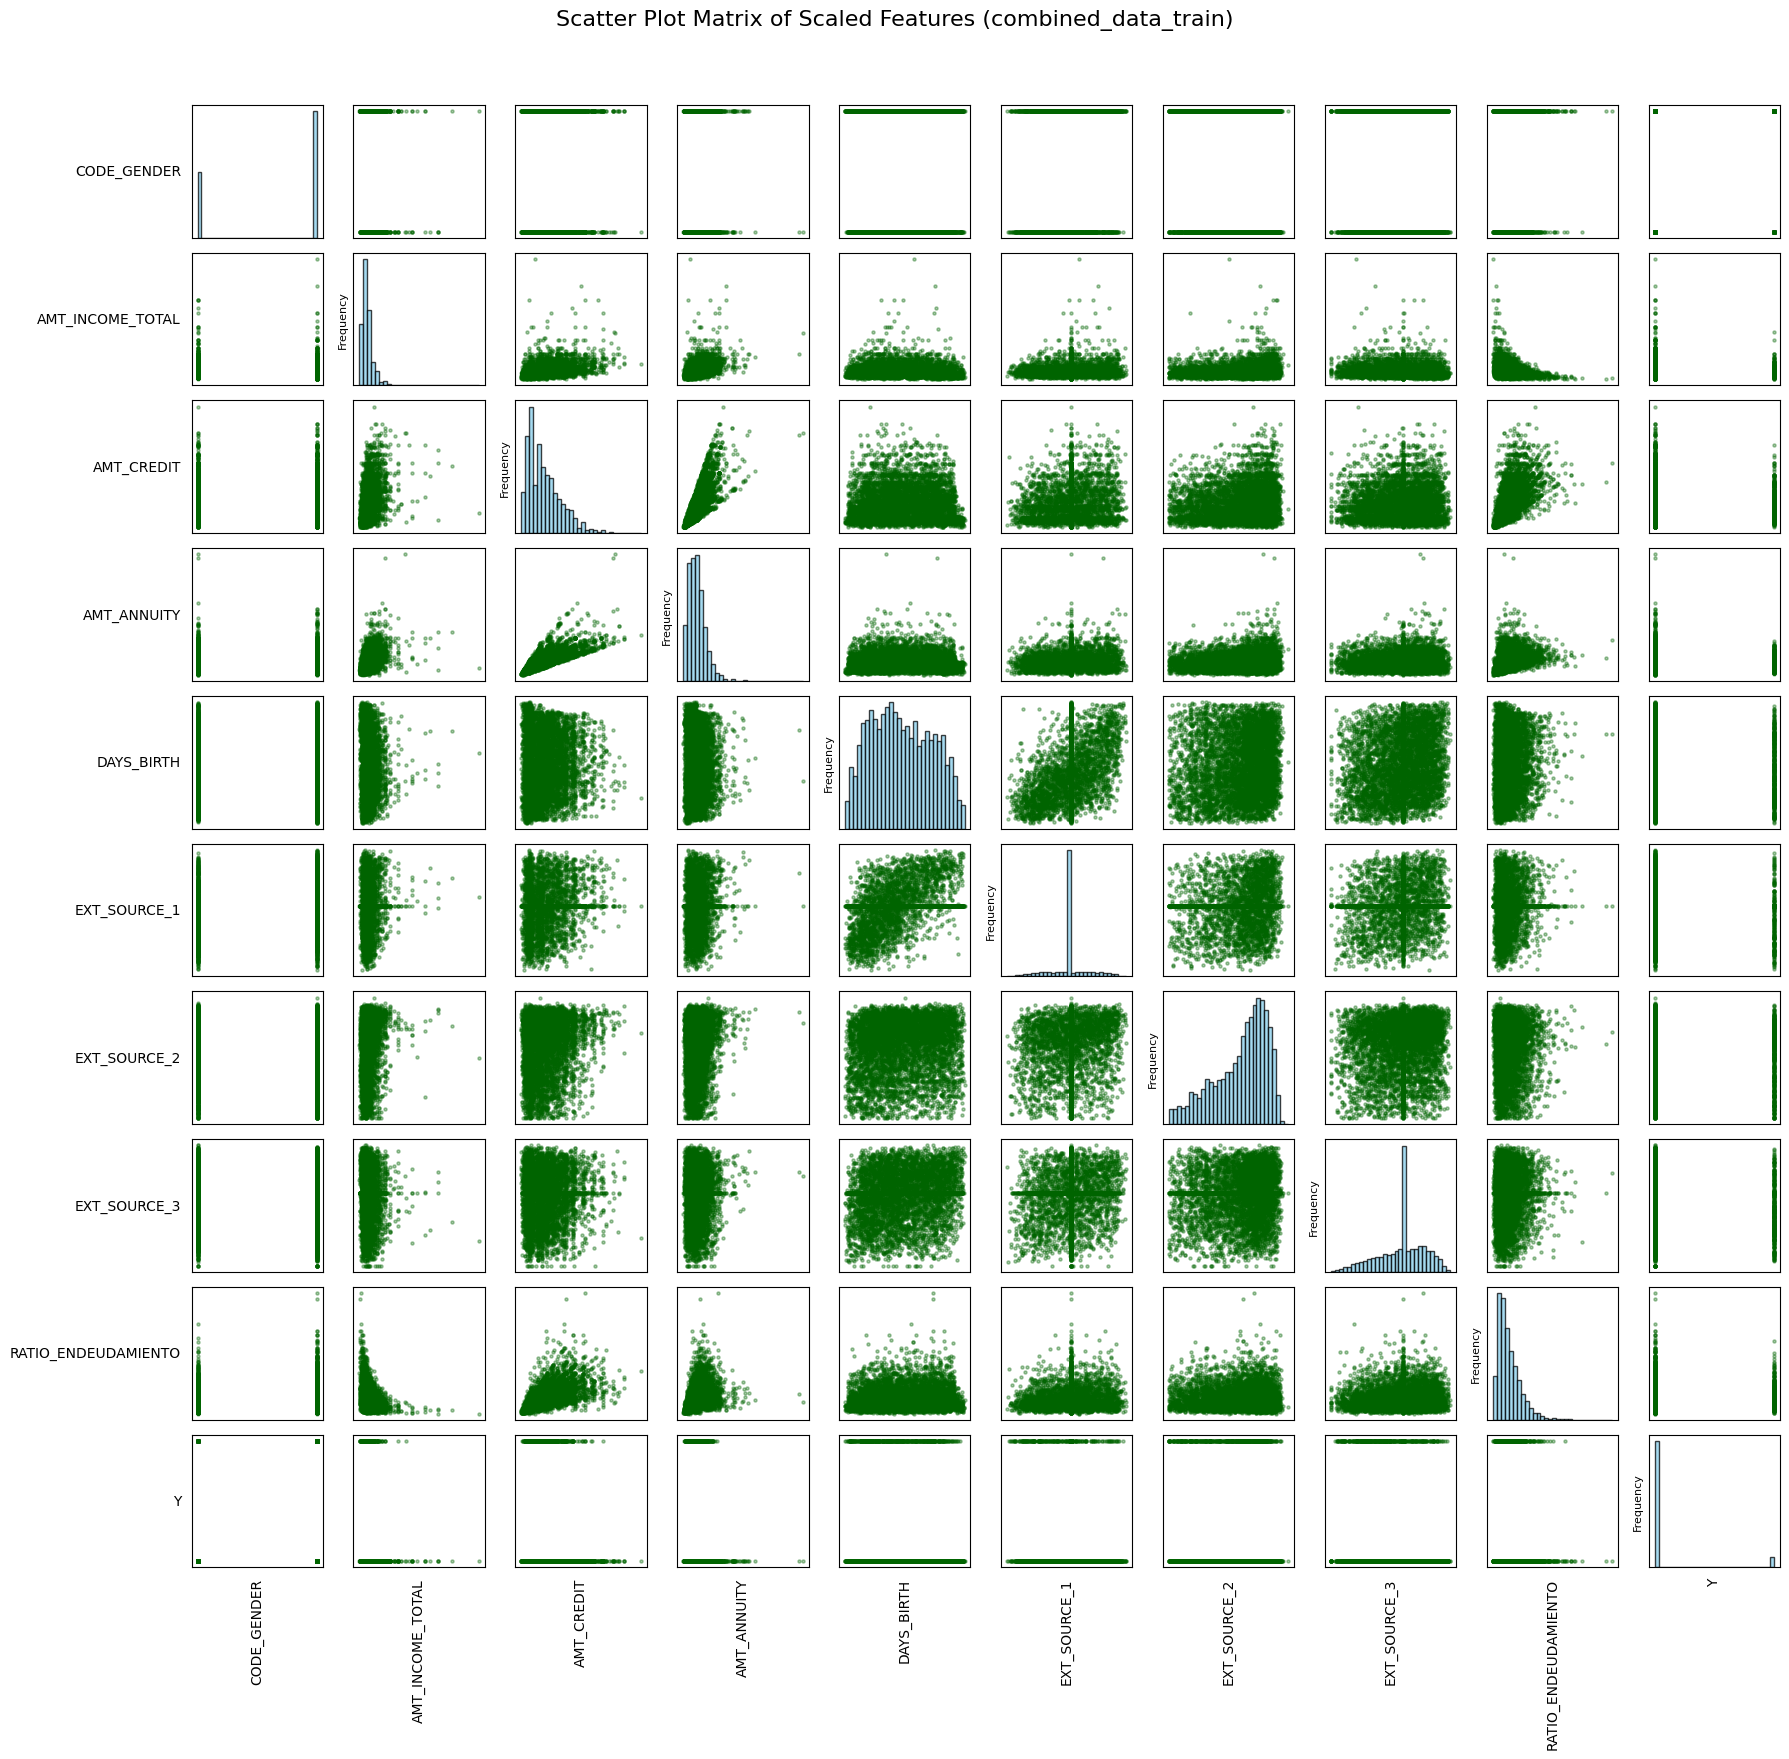

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scatter_matrix(data, feature_names, title, max_points=6000):
    rng = np.random.default_rng(42)
    if data.shape[0] > max_points:
        sample_idx = rng.choice(data.shape[0], size=max_points, replace=False)
        plot_data = data[sample_idx]
    else:
        plot_data = data

    n_features = plot_data.shape[1]
    fig_size = max(12, n_features * 1.8)
    fig, axes = plt.subplots(n_features, n_features, figsize=(fig_size, fig_size))

    for i in range(n_features):
        for j in range(n_features):
            ax = axes[i, j]
            if i == j:
                ax.hist(plot_data[:, i], bins=30, alpha=0.75, color='skyblue', edgecolor='black')
                ax.set_ylabel('Frequency', fontsize=8)
            else:
                ax.scatter(plot_data[:, j], plot_data[:, i], alpha=0.35, s=5, color='darkgreen')
                ax.set_aspect('auto')

            if i == n_features - 1:
                ax.set_xlabel(feature_names[j], rotation=90, ha='center', fontsize=10)
            else:
                ax.set_xticks([])

            if j == 0:
                ax.set_ylabel(feature_names[i], rotation=0, ha='right', va='center', fontsize=10)
            else:
                ax.set_yticks([])

            ax.tick_params(axis='both', which='both', length=0)
            ax.set_xticklabels([])
            ax.set_yticklabels([])

    plt.suptitle(title, y=1.005, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

feature_names = list(X_train_pre_scaler.columns) + ['Y']

plot_scatter_matrix(
    combined_data_train_pre_scaler,
    feature_names,
    'Scatter Plot Matrix of Features Before StandardScaler (combined_data_train_pre_scaler)'
)

#Si quieres comparar con las variables escaladas, descomenta esta llamada.
plot_scatter_matrix(
    combined_data_train,
    feature_names,
    'Scatter Plot Matrix of Scaled Features (combined_data_train)'
)

# Diseño aquitectura de modelo

## Informacion de ratios candidatos sobre TARGET

Se comparan los ratios financieros candidatos frente a `TARGET` con correlacion de Pearson, correlacion de Spearman e informacion mutua. El objetivo es identificar cual de estas combinaciones contiene mas senal predictiva antes de construir el modelo base.

,ratio,pearson_TARGET,spearman_TARGET,mutual_information_TARGET,abs_pearson_TARGET,abs_spearman_TARGET
0,AMT_ANNUITY / AMT_CREDIT,0.01270,0.03026,0.01947,0.01270,0.03026
1,AMT_ANNUITY / AMT_INCOME_TOTAL,0.01427,0.01843,0.00662,0.01427,0.01843
2,AMT_CREDIT / AMT_INCOME_TOTAL,-0.00773,-0.00180,0.00413,0.00773,0.00180


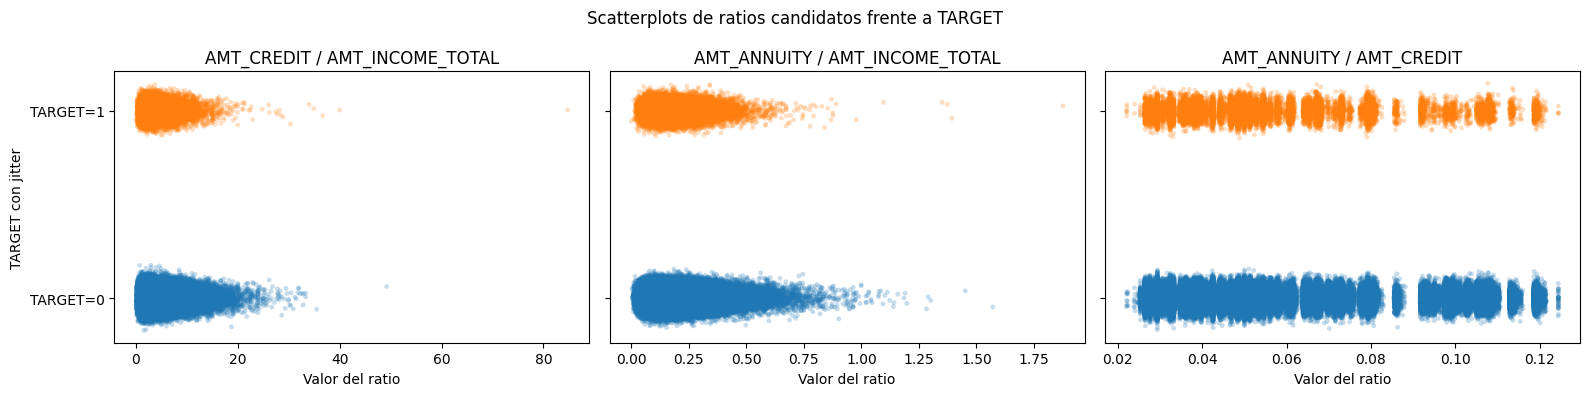

In [21]:
from sklearn.feature_selection import mutual_info_classif

ratio_candidates = {
    'AMT_CREDIT / AMT_INCOME_TOTAL': df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan),
    'AMT_ANNUITY / AMT_INCOME_TOTAL': df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan),
    'AMT_ANNUITY / AMT_CREDIT': df['AMT_ANNUITY'] / df['AMT_CREDIT'].replace(0, np.nan),
}

ratio_target_df = pd.DataFrame(ratio_candidates)
ratio_target_df['TARGET'] = df['TARGET']
ratio_target_df = ratio_target_df.replace([np.inf, -np.inf], np.nan).dropna()

ratio_metrics = []
for ratio_name in ratio_candidates:
    valid_data = ratio_target_df[[ratio_name, 'TARGET']].dropna()
    pearson_corr = valid_data[ratio_name].corr(valid_data['TARGET'], method='pearson')
    spearman_corr = valid_data[ratio_name].corr(valid_data['TARGET'], method='spearman')

    if valid_data[ratio_name].nunique() > 1:
        mutual_info = mutual_info_classif(
            valid_data[[ratio_name]],
            valid_data['TARGET'].astype(int),
            discrete_features=False,
            random_state=42,
        )[0]
    else:
        mutual_info = np.nan

    ratio_metrics.append({
        'ratio': ratio_name,
        'pearson_TARGET': pearson_corr,
        'spearman_TARGET': spearman_corr,
        'mutual_information_TARGET': mutual_info,
        'abs_pearson_TARGET': abs(pearson_corr),
        'abs_spearman_TARGET': abs(spearman_corr),
    })

ratio_metrics_df = (
    pd.DataFrame(ratio_metrics)
    .sort_values('mutual_information_TARGET', ascending=False)
    .reset_index(drop=True)
)

display(
    ratio_metrics_df.style.format({
        'pearson_TARGET': '{:.5f}',
        'spearman_TARGET': '{:.5f}',
        'mutual_information_TARGET': '{:.5f}',
        'abs_pearson_TARGET': '{:.5f}',
        'abs_spearman_TARGET': '{:.5f}',
    })
)

ratio_plot_df = ratio_target_df.melt(
    id_vars='TARGET',
    value_vars=list(ratio_candidates.keys()),
    var_name='ratio',
    value_name='ratio_value',
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
rng = np.random.default_rng(42)

for ax, ratio_name in zip(axes, ratio_candidates.keys()):
    scatter_data = ratio_target_df[[ratio_name, 'TARGET']].dropna().copy()
    scatter_data['TARGET_jitter'] = scatter_data['TARGET'] + rng.normal(
        loc=0,
        scale=0.035,
        size=len(scatter_data),
    )

    sns.scatterplot(
        data=scatter_data,
        x=ratio_name,
        y='TARGET_jitter',
        hue='TARGET',
        alpha=0.25,
        s=12,
        linewidth=0,
        ax=ax,
        legend=False,
    )
    ax.set_title(ratio_name)
    ax.set_xlabel('Valor del ratio')
    ax.set_ylabel('TARGET con jitter' if ax is axes[0] else '')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['TARGET=0', 'TARGET=1'])

plt.suptitle('Scatterplots de ratios candidatos frente a TARGET')
plt.tight_layout()
plt.show()

Se escoje el ratio AMT_CREDIT / AMT_INCOME_TOTAL, que es la capa que mejor refleja la idea de endeudamiento. Sin embargo, tiene los menores valores en las tres métricas. 

Evaluamos tres ratios candidatos por dependencia con el target (tabla X); aunque AMT_ANNUITY/AMT_CREDIT mostró la mayor dependencia, optamos por AMT_CREDIT/AMT_INCOME_TOTAL por su interpretabilidad como ratio de endeudamiento estándar, priorizando la restricción de dominio sobre la señal marginal, dado que el ratio actúa como aporte estructural.

## Capa custom: ratio de endeudamiento saturado

Se implementa una capa Keras 3 (multi-backend, vía `keras.ops`) que encapsula el ratio
de endeudamiento `AMT_CREDIT / AMT_INCOME_TOTAL` como aporte estructural al modelo.

Decisiones de diseño:
- **Cálculo interno (#2):** la capa recibe el vector de features **ya escalado** y
  extrae internamente las columnas de `AMT_CREDIT` y `AMT_INCOME_TOTAL` por índice. El
  ratio se calcula, por tanto, sobre variables estandarizadas (media 0, varianza 1), no
  en unidades originales.
- **Saturación (#3):** `tanh(ratio / k)` con `k` constante (no entrenable). Se elige
  `tanh` frente a `clip` porque es suave y diferenciable en todo el dominio (el `clip`
  anula el gradiente fuera del rango), y porque acota la salida a `(-1, 1)`.
- **Salida (#4):** la capa devuelve **solo** el ratio saturado (escalar); el resto de
  features se concatena fuera de la capa, antes de las densas.

> **Nota numérica (limitación conocida).** Como `AMT_CREDIT` y `AMT_INCOME_TOTAL` están
> estandarizadas (media 0), el denominador cruza el cero: el ratio es de cola pesada
> (tipo Cauchy) y puede cambiar de signo. El diseño lo absorbe porque (a) `tanh` acota
> la salida, (b) se usa una división con `eps` para evitar NaN y (c) `k` se calibra con
> un percentil de `|ratio|`, robusto a esa cola.

In [22]:
import keras
import tensorflow as tf

class _Ops:
    @staticmethod
    def tanh(x):
        return tf.math.tanh(x)

    @staticmethod
    def reshape(x, shape):
        return tf.reshape(x, shape)

    @staticmethod
    def take(x, indices, axis=0):
        return tf.gather(x, indices, axis=axis)

ops = _Ops()


@keras.saving.register_keras_serializable()
class DebtRatioSaturationLayer(keras.layers.Layer):
    """Ratio de endeudamiento saturado, estilo capa custom multi-backend.

    Calcula AMT_CREDIT / AMT_INCOME_TOTAL sobre el vector YA escalado (extrae las
    columnas por indice) y lo satura con tanh(ratio / k). Devuelve un escalar por
    muestra, shape (batch, 1).

    Diseno:
    - k es CONSTANTE (no entrenable) -> calculo directo en `call`, sin `build` ni
      `add_weight`. (Si en el futuro se quisiera k entrenable, ahi entraria el patron
      build/add_weight con un peso escalar.)
    - tanh (no clip): suave y diferenciable en todo el dominio, ademas acota la salida
      a (-1, 1), lo que absorbe la cola pesada de dividir dos variables estandarizadas.
    - eps en el denominador: evita NaN cuando el ingreso escalado pasa por cero.
    """

    def __init__(self, credit_idx, income_idx, k, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.credit_idx = int(credit_idx)
        self.income_idx = int(income_idx)
        self.k = float(k)
        self.eps = float(eps)

    def call(self, inputs):
        credit = inputs[:, self.credit_idx]
        income = inputs[:, self.income_idx]
        ratio = credit / (income + self.eps)        # division segura
        saturated = ops.tanh(ratio / self.k)        # acota a (-1, 1)
        return ops.reshape(saturated, (-1, 1))

    def compute_output_shape(self, input_shape):
        return (input_shape[0], 1)

    def get_config(self):
        config = super().get_config()
        config.update({
            'credit_idx': self.credit_idx,
            'income_idx': self.income_idx,
            'k': self.k,
            'eps': self.eps,
        })
        return config

### Calibración de k

El valor de `k` se deriva del **propio dato**: se calcula el ratio
`AMT_CREDIT / AMT_INCOME_TOTAL` sobre `X_train` **ya escalado** (con la misma división
segura que usa la capa) y se toma un percentil alto de `|ratio|`. Al ser un percentil,
es robusto a la cola pesada que produce el denominador cerca de cero. Así la zona
casi lineal de `tanh` cubre el grueso de la distribución y solo los extremos saturan.

In [23]:
# Features que entran al modelo: todas menos la RATIO_ENDEUDAMIENTO precalculada
# (era analisis del EDA). Las amounts SI entran al vector porque la capa las consume
# por indice; se excluyen del passthrough mas abajo.
model_feature_cols = [c for c in X_train.columns if c != 'RATIO_ENDEUDAMIENTO']

X_train_model = X_train[model_feature_cols]
X_test_model = X_test[model_feature_cols]

# Indices derivados por nombre (robusto a cambios de orden de columnas).
credit_idx = model_feature_cols.index('AMT_CREDIT')
income_idx = model_feature_cols.index('AMT_INCOME_TOTAL')

# Passthrough = resto de features escaladas (sin las dos amounts consumidas por la capa).
consumed = {'AMT_CREDIT', 'AMT_INCOME_TOTAL'}
passthrough_idx = [i for i, c in enumerate(model_feature_cols) if c not in consumed]

# --- Calibracion de k sobre el ratio YA escalado (misma division segura que la capa) ---
eps = 1e-6
ratio_scaled = X_train_model['AMT_CREDIT'] / (X_train_model['AMT_INCOME_TOTAL'] + eps)

# Percentil de |ratio|: robusto a la cola pesada por el denominador cerca de 0.
# Con k = p90, ~90% de las muestras caen en la zona casi lineal de tanh (|x| < 1)
# y la cola satura suavemente.
PERC = 90
k = float(np.percentile(np.abs(ratio_scaled), PERC))

print(f'Features del modelo ({len(model_feature_cols)}):', model_feature_cols)
print('credit_idx / income_idx:', credit_idx, income_idx)
print('passthrough_idx:', passthrough_idx)
print(f'k (p{PERC} de |ratio escalado|) = {k:.4f}')
print(ratio_scaled.describe())

Features del modelo (8): ['CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
credit_idx / income_idx: 2 1
passthrough_idx: [0, 3, 4, 5, 6, 7]
k (p90 de |ratio escalado|) = 17.3997
count    246008.000000
mean          1.247682
std          34.564411
min       -6393.557404
25%          -1.438004
50%           1.704037
75%           4.155763
max        2811.959704
dtype: float64


## Arquitectura compartida (modelo base / modelo FAIR)

La misma función `build_model` construye **tanto el modelo base como el FAIR**: misma
capa custom, mismos hiperparámetros y misma topología. La única diferencia entre ambos
será la **función de pérdida** que se pase en `.compile()` (el término de fairness),
de modo que la comparación Base vs. FAIR aísle limpiamente ese efecto.

El modelo recibe el vector escalado **sin** `RATIO_ENDEUDAMIENTO` (esa columna fue solo
análisis del EDA). Dentro, la capa custom extrae `AMT_CREDIT`/`AMT_INCOME_TOTAL` y
emite el ratio saturado, que se concatena con el resto de features (passthrough) antes
de las capas densas.

In [24]:
def build_model(
    input_dim,
    credit_idx,
    income_idx,
    passthrough_idx,
    k,
    hidden_units=(64, 32),
    dropout=0.2,
    name='credit_default_model',
):
    """Arquitectura compartida Base/FAIR.

    Recibe el vector escalado completo (sin RATIO_ENDEUDAMIENTO). La capa custom
    extrae credit/income por indice y produce el ratio saturado; ese escalar se
    concatena con las features passthrough (resto de variables, sin las amounts
    consumidas) antes de las capas densas. La unica diferencia entre el modelo base
    y el FAIR sera la loss en el .compile(), no la arquitectura.
    """
    inputs = keras.Input(shape=(input_dim,), name='features')

    # Ratio de endeudamiento saturado (salida escalar de la capa custom).
    saturated_ratio = DebtRatioSaturationLayer(
        credit_idx=credit_idx,
        income_idx=income_idx,
        k=k,
        name='debt_ratio_saturation',
    )(inputs)

    # Resto de features escaladas (passthrough), sin las dos amounts consumidas.
    passthrough = keras.layers.Lambda(
        lambda t: ops.take(t, passthrough_idx, axis=1),
        output_shape=(len(passthrough_idx),),
        name='passthrough_features',
    )(inputs)

    # Concatenacion fuera de la capa custom (decision de diseno #4).
    x = keras.layers.Concatenate(name='concat')([passthrough, saturated_ratio])
    for i, units in enumerate(hidden_units):
        x = keras.layers.Dense(units, activation='relu', name=f'dense_{i}')(x)
        if dropout:
            x = keras.layers.Dropout(dropout, name=f'dropout_{i}')(x)
    outputs = keras.layers.Dense(1, activation='sigmoid', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name=name)


# Instancia de referencia (SIN compilar: la loss la anade cada variante base/FAIR).
model = build_model(
    input_dim=len(model_feature_cols),
    credit_idx=credit_idx,
    income_idx=income_idx,
    passthrough_idx=passthrough_idx,
    k=k,
)
model.summary()

2026-06-23 18:16:56.486631: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 18:16:56.671807: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 18:16:56.671900: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 18:16:56.674425: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 18:16:56.674487: I tensorflow/compile

Model: "credit_default_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 features (InputLayer)       [(None, 8)]                  0         []                            
                                                                                                  
 passthrough_features (Lamb  (None, 6)                    0         ['features[0][0]']            
 da)                                                                                              
                                                                                                  
 debt_ratio_saturation (Deb  (None, 1)                    0         ['features[0][0]']            
 tRatioSaturationLayer)                                                                           
                                                                               

ead NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 18:16:56.932804: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


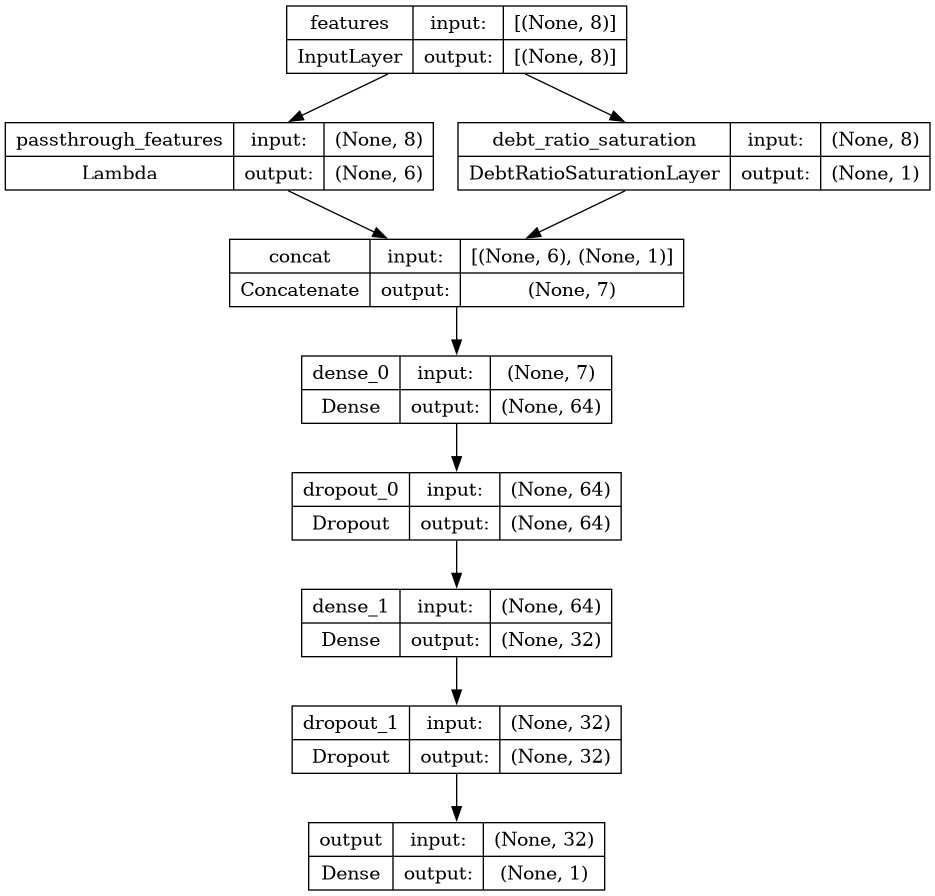

In [25]:
# Visualización del grafo del modelo (requiere pydot + Graphviz)
from IPython.display import Image, display as ipy_display
try:
    from tensorflow.keras.utils import plot_model
    _png = "model_plot_9tiendas.png"
    plot_model(model, to_file=_png, show_shapes=True, show_layer_names=True,
               expand_nested=True, dpi=96)
    ipy_display(Image(_png))
except Exception as _e:
    print(f"plot_model no disponible ({_e})")
    print("Instala con:  conda install -c conda-forge pydot python-graphviz")

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

In [27]:
base_model = model.fit(
    X_train_model,
    y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    verbose=2,
)

Epoch 1/100


2026-06-23 18:16:58.375652: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-06-23 18:16:58.498156: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x77664d099530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-23 18:16:58.498224: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-06-23 18:16:58.541271: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-23 18:16:58.620606: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2026-06-23 18:16:58.862678: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifeti

865/865 - 9s - loss: 0.2737 - accuracy: 0.9174 - auc: 0.6784 - val_loss: 0.2561 - val_accuracy: 0.9181 - val_auc: 0.7322 - 9s/epoch - 10ms/step
Epoch 2/100
865/865 - 5s - loss: 0.2602 - accuracy: 0.9194 - auc: 0.7071 - val_loss: 0.2553 - val_accuracy: 0.9181 - val_auc: 0.7341 - 5s/epoch - 5ms/step
Epoch 3/100
865/865 - 9s - loss: 0.2586 - accuracy: 0.9194 - auc: 0.7117 - val_loss: 0.2553 - val_accuracy: 0.9181 - val_auc: 0.7345 - 9s/epoch - 11ms/step
Epoch 4/100
865/865 - 12s - loss: 0.2575 - accuracy: 0.9194 - auc: 0.7155 - val_loss: 0.2557 - val_accuracy: 0.9181 - val_auc: 0.7338 - 12s/epoch - 14ms/step
Epoch 5/100
865/865 - 9s - loss: 0.2574 - accuracy: 0.9194 - auc: 0.7157 - val_loss: 0.2549 - val_accuracy: 0.9181 - val_auc: 0.7345 - 9s/epoch - 10ms/step
Epoch 6/100
865/865 - 11s - loss: 0.2570 - accuracy: 0.9194 - auc: 0.7167 - val_loss: 0.2549 - val_accuracy: 0.9181 - val_auc: 0.7344 - 11s/epoch - 13ms/step
Epoch 7/100
865/865 - 11s - loss: 0.2565 - accuracy: 0.9194 - auc: 0.7190

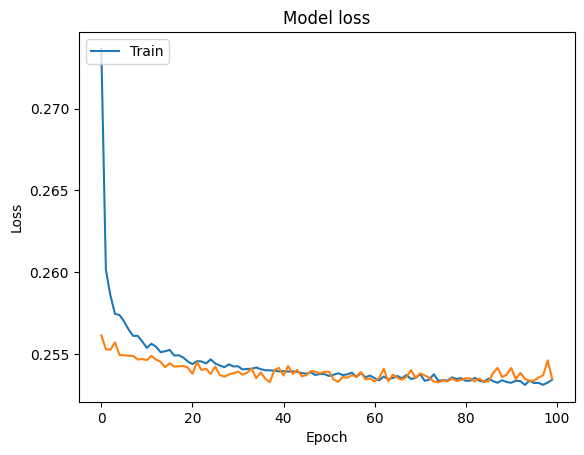

In [28]:
plt.plot(base_model.history['loss'])
plt.plot(base_model.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

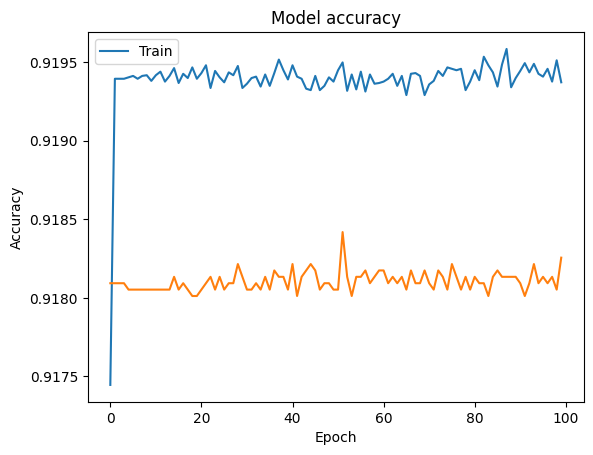

In [29]:
plt.plot(base_model.history['accuracy'])
plt.plot(base_model.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')


In [30]:
import scipy.stats
import numpy as np

# Obtener las predicciones del modelo en los datos de entrenamiento
y_pred_proba = model.predict(X_train_model)
y_pred = y_pred_proba.flatten()

# s_train es la variable sensible (género) alineada con X_train desde el split
sensitive_variable_gender = s_train.to_numpy()

# Calcular la correlación de Pearson
pearson_corr, _ = scipy.stats.pearsonr(y_pred, sensitive_variable_gender)
print(f"Correlación de Pearson entre la probabilidad predicha y el género: {pearson_corr:.4f}")

# Calcular la correlación de Spearman
spearman_corr, _ = scipy.stats.spearmanr(y_pred, sensitive_variable_gender)
print(f"Correlación de Spearman entre la probabilidad predicha y el género: {spearman_corr:.4f}")

7688/7688 [==============================] - 19s 3ms/step
Correlación de Pearson entre la probabilidad predicha y el género: -0.2302
Correlación de Spearman entre la probabilidad predicha y el género: -0.2840


## Función de pérdida FAIR
Se implementa una función de pérdida custom que combina la pérdida binaria estándar (binary crossentropy) con un término de fairness que penaliza la dependencia entre la predicción y la variable sensible `CODE_GENDER`. La idea es minimizar la pérdida de predicción mientras se asegura que el modelo no discrimine en función del género.

In [31]:
import keras
import tensorflow as tf
import numpy as np


class CustomFairnessLoss(keras.losses.Loss):
    """BCE + penalización por correlación de Pearson con la variable sensible.

    y_true_extended: tensor (batch, 2) con columnas [y_true_real, variable_sensible].
    y_pred_single:   predicciones del modelo, shape (batch, 1).
    """

    def __init__(self, lambda_correlation=0.1, name="custom_fairness_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_correlation = lambda_correlation
        self.bce = keras.losses.BinaryCrossentropy(from_logits=False)

    def call(self, y_true_extended, y_pred_single):
        y_true_actual = y_true_extended[:, 0]
        s_true = y_true_extended[:, 1]

        y_pred_single = tf.squeeze(y_pred_single, axis=-1)

        # Pérdida BCE principal
        bce_loss = self.bce(y_true_actual, y_pred_single)

        # Penalización: correlación de Pearson entre predicción y variable sensible
        y_pred_mean = tf.reduce_mean(y_pred_single)
        s_true_mean = tf.reduce_mean(s_true)

        y_pred_centered = y_pred_single - y_pred_mean
        s_true_centered = s_true - s_true_mean

        covariance = tf.reduce_mean(y_pred_centered * s_true_centered)
        y_pred_std = tf.math.reduce_std(y_pred_single)
        s_true_std = tf.math.reduce_std(s_true)

        denominator = (y_pred_std * s_true_std) + keras.backend.epsilon()
        correlation = covariance / denominator

        correlation_penalty = tf.square(correlation)

        return bce_loss + self.lambda_correlation * correlation_penalty

    def get_config(self):
        config = super().get_config()
        config.update({"lambda_correlation": self.lambda_correlation})
        return config


class FairModel(keras.Model):
    """Model con train_step/test_step custom para CustomFairnessLoss.

    El target y_extended tiene 2 columnas [y_true, s].
    - compiled_loss recibe y_extended completo → CustomFairnessLoss lo gestiona.
    - compiled_metrics reciben sólo y_true[:, 0] (1 columna) → accuracy, AUC funcionan.
    """

    def train_step(self, data):
        # Desempaquetado manual: evita importar keras.engine que cambia entre versiones
        if len(data) == 3:
            x, y_extended, sample_weight = data
        else:
            x, y_extended = data
            sample_weight = None

        y_true = tf.expand_dims(y_extended[:, 0], axis=-1)

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compiled_loss(
                y_extended, y_pred, sample_weight,
                regularization_losses=self.losses,
            )

        self.optimizer.minimize(loss, self.trainable_variables, tape=tape)
        self.compiled_metrics.update_state(y_true, y_pred, sample_weight)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if len(data) == 3:
            x, y_extended, sample_weight = data
        else:
            x, y_extended = data
            sample_weight = None

        y_true = tf.expand_dims(y_extended[:, 0], axis=-1)
        y_pred = self(x, training=False)
        self.compiled_loss(
            y_extended, y_pred, sample_weight,
            regularization_losses=self.losses,
        )
        self.compiled_metrics.update_state(y_true, y_pred, sample_weight)
        return {m.name: m.result() for m in self.metrics}


print("CustomFairnessLoss y FairModel definidos correctamente.")


CustomFairnessLoss y FairModel definidos correctamente.


### Entrenamiento del modelo FAIR

La función de pérdida necesita el target real **y** la variable sensible juntos. Se construye `y_train_fair` combinando `y_train` y `s_train` en un tensor de forma `(N, 2)`.

El modelo FAIR usa la misma arquitectura que el base (`build_model`) y solo difiere en la loss compilada.

In [32]:
# El target del modelo FAIR combina y_true + variable sensible en una sola matriz (N, 2)
# para que la loss pueda acceder a ambas columnas dentro de call().
y_train_fair = np.column_stack([y_train.to_numpy(), s_train.to_numpy()]).astype(np.float32)
print("y_train_fair shape:", y_train_fair.shape, "| primeras 3 filas:", y_train_fair[:3])

# build_model construye el grafo funcional; FairModel lo envuelve con train/test_step custom.
_backbone = build_model(
    input_dim=len(model_feature_cols),
    credit_idx=credit_idx,
    income_idx=income_idx,
    passthrough_idx=passthrough_idx,
    k=k,
    name='_backbone_fair',
)
model_fair = FairModel(
    inputs=_backbone.inputs,
    outputs=_backbone.outputs,
    name='credit_default_model_fair',
)
del _backbone

model_fair.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=CustomFairnessLoss(lambda_correlation=0.9),
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

fair_history = model_fair.fit(
    X_train_model,
    y_train_fair,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    verbose=2,
)


y_train_fair shape: (246008, 2) | primeras 3 filas: [[0. 1.]
 [0. 0.]
 [1. 0.]]
Epoch 1/100
865/865 - 16s - loss: 0.2807 - accuracy: 0.9178 - auc: 0.6686 - val_loss: 0.2626 - val_accuracy: 0.9181 - val_auc: 0.7245 - 16s/epoch - 18ms/step
Epoch 2/100
865/865 - 13s - loss: 0.2659 - accuracy: 0.9194 - auc: 0.6992 - val_loss: 0.2606 - val_accuracy: 0.9181 - val_auc: 0.7279 - 13s/epoch - 15ms/step
Epoch 3/100
865/865 - 16s - loss: 0.2636 - accuracy: 0.9194 - auc: 0.7067 - val_loss: 0.2611 - val_accuracy: 0.9181 - val_auc: 0.7294 - 16s/epoch - 19ms/step
Epoch 4/100
865/865 - 10s - loss: 0.2630 - accuracy: 0.9194 - auc: 0.7077 - val_loss: 0.2604 - val_accuracy: 0.9181 - val_auc: 0.7294 - 10s/epoch - 11ms/step
Epoch 5/100
865/865 - 12s - loss: 0.2626 - accuracy: 0.9194 - auc: 0.7091 - val_loss: 0.2605 - val_accuracy: 0.9181 - val_auc: 0.7288 - 12s/epoch - 14ms/step
Epoch 6/100
865/865 - 11s - loss: 0.2619 - accuracy: 0.9194 - auc: 0.7129 - val_loss: 0.2603 - val_accuracy: 0.9181 - val_auc: 0.7

### Evaluación de equidad: correlación predicción–género

Se mide la correlación de Pearson y Spearman entre la probabilidad predicha y `CODE_GENDER` para el modelo FAIR y el modelo base. Una reducción de estas correlaciones indica que el modelo FAIR discrimina menos por género, aunque puede haber un coste en métricas predictivas.

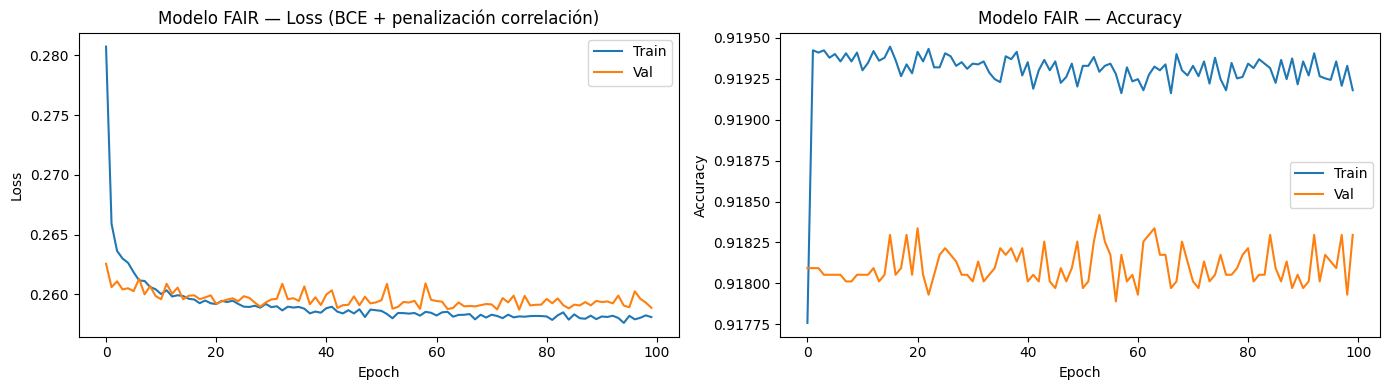

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(fair_history.history['loss'], label='Train')
axes[0].plot(fair_history.history['val_loss'], label='Val')
axes[0].set_title('Modelo FAIR — Loss (BCE + penalización correlación)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(fair_history.history['accuracy'], label='Train')
axes[1].plot(fair_history.history['val_accuracy'], label='Val')
axes[1].set_title('Modelo FAIR — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


In [34]:
import scipy.stats

sensitive_variable_gender = s_train.to_numpy()

# --- Modelo base ---
y_pred_base = model.predict(X_train_model).flatten()
pearson_base, _ = scipy.stats.pearsonr(y_pred_base, sensitive_variable_gender)
spearman_base, _ = scipy.stats.spearmanr(y_pred_base, sensitive_variable_gender)

# --- Modelo FAIR ---
y_pred_fair = model_fair.predict(X_train_model).flatten()
pearson_fair, _ = scipy.stats.pearsonr(y_pred_fair, sensitive_variable_gender)
spearman_fair, _ = scipy.stats.spearmanr(y_pred_fair, sensitive_variable_gender)

print("Correlación predicción–género (train)")
print(f"{'Modelo':<12} {'Pearson':>10} {'Spearman':>10}")
print("-" * 35)
print(f"{'Base':<12} {pearson_base:>10.4f} {spearman_base:>10.4f}")
print(f"{'FAIR':<12} {pearson_fair:>10.4f} {spearman_fair:>10.4f}")
print(f"{'Reducción':<12} {abs(pearson_base) - abs(pearson_fair):>10.4f} {abs(spearman_base) - abs(spearman_fair):>10.4f}")


7688/7688 [==============================] - 32s 4ms/step
Correlación predicción–género (train)
Modelo          Pearson   Spearman
-----------------------------------
Base            -0.2302    -0.2840
FAIR             0.0006    -0.0686
Reducción        0.2296     0.2154
